In [1]:
#Import Libraies and file path

from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/ITE 353_T2_2025'

books_file_path = os.path.join(folder_path, 'Books.csv')
users_file_path = os.path.join(folder_path, 'Users.csv')
ratings_file_path = os.path.join(folder_path, 'Ratings.csv')


Mounted at /content/drive


**Business Problem **

Poor recommendations reduce user satisfaction and engagement. The goal of this project is build a book recommendation system that suggests books based on user preferences and past ratings.

**Problem Formulation**

This problem is formulated as a recommendation system problem using collaborative filtering.

In [2]:
#Collect and Label Data

books = pd.read_csv(books_file_path, encoding="latin-1")
users = pd.read_csv(users_file_path, encoding="latin-1")
ratings = pd.read_csv(ratings_file_path, encoding="latin-1")

print(books.shape)
print(users.shape)
print(ratings.shape)

/tmp/ipython-input-314223412.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(books_file_path, encoding="latin-1")


(271360, 8)
(278858, 3)
(1149780, 3)


In [3]:
#Evalute Data

books.head(3)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...


In [4]:
users.head(5)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
ratings.head(3)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


In [6]:
#Check missing values

books.isnull().sum()
users.isnull().sum()
ratings.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


In [7]:
#Check the duplicate values

books.duplicated().sum()
ratings.duplicated().sum()
users.duplicated().sum()

np.int64(0)

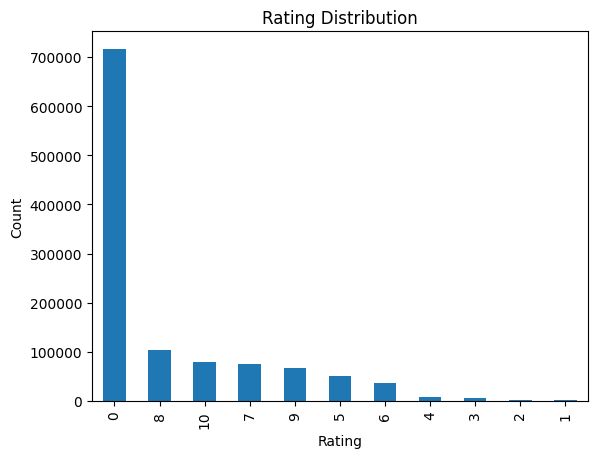

In [8]:
#Rating Distribution

plt.figure()
ratings['Book-Rating'].value_counts().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [9]:
#Feature Engineering

books = books[['ISBN', 'Book-Title', 'Book-Author']]
data = ratings.merge(books, on='ISBN')
data = data[data['Book-Rating']>0]
books.head(3)

,ISBN,Book-Title,Book-Author
0,0195153448,Classical Mythology,Mark P. O. Morford
1,0002005018,Clara Callan,Richard Bruce Wright
2,0060973129,Decision in Normandy,Carlo D'Este


In [10]:
#Reduce the data size (filter active users and popular books)

user_counts = data['User-ID'].value_counts()
active_users = user_counts[user_counts >= 40].index
data = data[data['User-ID'].isin(active_users)]

book_counts = data['Book-Title'].value_counts()
popular_books = book_counts[book_counts >= 50].index
data = data[data['Book-Title'].isin(popular_books)]
data.shape

(6741, 5)

In [11]:
#Select and Train Model

#Create user-book matrix

user_book_matrix = data.pivot_table(
    index='User-ID',
    columns='Book-Title',
    values='Book-Rating')
user_book_matrix.fillna(0, inplace=True)
user_book_matrix.head()


Book-Title,1st to Die: A Novel,2nd Chance,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Painted House,A Time to Kill,Angels &amp; Demons,B Is for Burglar (Kinsey Millhone Mysteries (Paperback)),Bridget Jones's Diary,Confessions of a Shopaholic (Summer Display Opportunity),Divine Secrets of the Ya-Ya Sisterhood: A Novel,...,Timeline,To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",Violets Are Blue,Watership Down,When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),White Oleander : A Novel,Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
User-ID,,,,,,,,,,,,,,,,,,,,,
254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,0.0,9.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
#Recommendation Model (Collaborative Filtering )

from sklearn.metrics.pairwise import cosine_similarity
book_similarity = cosine_similarity(user_book_matrix.T)
book_similarity_df = pd.DataFrame(
    book_similarity,
    index=user_book_matrix.columns,
    columns=user_book_matrix.columns)
book_similarity_df.head()

Book-Title,1st to Die: A Novel,2nd Chance,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Painted House,A Time to Kill,Angels &amp; Demons,B Is for Burglar (Kinsey Millhone Mysteries (Paperback)),Bridget Jones's Diary,Confessions of a Shopaholic (Summer Display Opportunity),Divine Secrets of the Ya-Ya Sisterhood: A Novel,...,Timeline,To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",Violets Are Blue,Watership Down,When the Wind Blows,Where the Heart Is (Oprah's Book Club (Paperback)),White Oleander : A Novel,Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
Book-Title,,,,,,,,,,,,,,,,,,,,,
1st to Die: A Novel,1.000000,0.230812,0.162128,0.103675,0.135735,0.138422,0.092889,0.117983,0.124941,0.100567,...,0.057167,0.092662,0.091756,0.211695,0.040462,0.176828,0.089645,0.090915,0.069146,0.045375
2nd Chance,0.230812,1.000000,0.054103,0.148795,0.181023,0.090312,0.056594,0.150776,0.096260,0.063454,...,0.076389,0.033786,0.051900,0.301709,0.051324,0.252554,0.074705,0.040563,0.077208,0.065149
A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),0.162128,0.054103,1.000000,0.114807,0.116376,0.058560,0.425733,0.091514,0.041656,0.099507,...,0.020456,0.072315,0.070565,0.063130,0.081301,0.052483,0.061237,0.052807,0.061544,0.017995
A Painted House,0.103675,0.148795,0.114807,1.000000,0.169878,0.088200,0.105721,0.110489,0.048190,0.122800,...,0.165404,0.075789,0.108650,0.080907,0.009931,0.150520,0.124873,0.126732,0.109961,0.049753
A Time to Kill,0.135735,0.181023,0.116376,0.169878,1.000000,0.044908,0.097840,0.108211,0.065071,0.074114,...,0.055989,0.092136,0.082948,0.097020,0.075161,0.100268,0.079000,0.007008,0.054374,0.033579


In [13]:
#Book Recommendation Function

def recommend_books(book_title, n=5):
    if book_title not in book_similarity_df.index:
        return "Book not found in the dataset."

    similar_scores = book_similarity_df[book_title].sort_values(ascending=False)
    return similar_scores.iloc[1:n+1]

In [18]:
#Test the model

recommend_books('The Da Vinci Code')


,The Da Vinci Code
Book-Title,
Angels &amp; Demons,0.311176
The Secret Life of Bees,0.178576
The Lovely Bones: A Novel,0.177643
Timeline,0.154731
She's Come Undone (Oprah's Book Club (Paperback)),0.154396


In [15]:
# Model Evaluation (Simple Recommendation Quality Check)

def evaluate_recommendation(book_title):
    print("Target Book:", book_title)
    print("\nRecommended Books:")

    recs = recommend_books(book_title, 5)
    print(recs)

evaluate_recommendation("The Da Vinci Code")


Target Book: The Da Vinci Code

Recommended Books:
Book-Title
Angels &amp; Demons                                  0.311176
The Secret Life of Bees                              0.178576
The Lovely Bones: A Novel                            0.177643
Timeline                                             0.154731
She's Come Undone (Oprah's Book Club (Paperback))    0.154396
Name: The Da Vinci Code, dtype: float64


In [16]:
# Simple Precision@K Evaluation

def precision_at_k(recommended_books, relevant_books, k=5):
    recommended_k = recommended_books[:k]
    relevant_set = set(relevant_books)

    hit_count = len([b for b in recommended_k if b in relevant_set])
    return hit_count / k

#(manual relevant books example)
recommended = list(recommend_books("The Da Vinci Code", 5))
relevant = recommended[:2]   # assume first 2 are relevant for demo

print("Precision@5:", precision_at_k(recommended, relevant, 5))


Precision@5: 0.4


In [17]:
# Simple Parameter Tuning Example

user_thresholds = [20, 50, 100]
book_thresholds = [10, 20, 50]

results = []

for u_th in user_thresholds:
    for b_th in book_thresholds:
        filtered_users = user_counts[user_counts > u_th].index
        filtered_books = book_counts[book_counts > b_th].index

        filtered_data = data[
            (data['User-ID'].isin(filtered_users)) &
            (data['Book-Title'].isin(filtered_books))
        ]

        results.append((u_th, b_th, len(filtered_data)))

print("Tuning Results:")
for r in results:
    print("User Th:", r[0], "Book Th:", r[1], "Remaining Data:", r[2])


Tuning Results:
User Th: 20 Book Th: 10 Remaining Data: 6741
User Th: 20 Book Th: 20 Remaining Data: 6741
User Th: 20 Book Th: 50 Remaining Data: 6541
User Th: 50 Book Th: 10 Remaining Data: 5689
User Th: 50 Book Th: 20 Remaining Data: 5689
User Th: 50 Book Th: 50 Remaining Data: 5528
User Th: 100 Book Th: 10 Remaining Data: 3169
User Th: 100 Book Th: 20 Remaining Data: 3169
User Th: 100 Book Th: 50 Remaining Data: 3082
